## Hallucination Detector for LLMs

This project builds a lightweight confidence model that predicts whether an LLM’s answer is correct using internal transformer signals rather than external verification. During inference, the system extracts features from the model’s final layer—such as accumulated attention evidence, residual stream magnitude, logit entropy, and top-k probabilities—and feeds them into a small classifier trained to estimate answer reliability. The result is a post-hoc hallucination detector that can flag low-confidence outputs or trigger abstention without modifying the underlying LLM.

Pipeline Overview:
1. Internal Data Capture: Uses hooks to grab specific numbers from the model's layers while it processes a prompt.

2. Feature Extraction: Organizes these numbers into usable categories:

    - Attention Data: How the model links different parts of the input.

    - Layer Changes: How much the data changes as it moves through the model.

    - Output Probabilities: How confident the model appears to be about its top word choices.

3. Dataset Construction: Tests the model on 4,000 samples from the LAMBADA dataset and labels each answer as right or wrong.

4. Testing & Analysis: Trains the detector and runs ablations to see which internal signals are actually helpful for catching errors.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig, BitsAndBytesConfig
from transformers.models.llama.modeling_llama import apply_rotary_pos_emb as apply_rotary_pos_emb
from datasets import load_dataset
from tqdm import tqdm
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix, f1_score
print('Done.')

Done.


In [2]:
from utils import get_hook_q, get_hook_k, get_res_hook
from utils import get_p_tot_log, get_head_magnitudes, get_logit_feats, extract_features
from utils import set_seed
print('Done.')

Done.


In [3]:
from model import HallucinationDetector
from model import stream_openai_lambada, generate_hallucination_dataset
from model import train_hallucination_detector
print('Done.')

Done.


In [4]:
from evals import evaluate_detector, run_kfold_evaluation
from evals import plot_trajectory_comparison, plot_trajectory_grid_scaled, plot_evidence_distribution
print('Done.')

Done.


### Load the model and define basic functionality

In [5]:
set_seed(2026)

In [6]:
# Model path
current_dir = os.getcwd()
model_path = os.path.join(current_dir, "TinyLlama-1.1B-Chat-v1.0")

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)

# Load Model 
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto",
    local_files_only=True
)

print(f"Model loaded onto: {model.device}")

`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded onto: cuda:0


In [7]:
# Get last layer
layer_idx = -1
target_layer = model.model.layers[layer_idx]

saved = {}

In [8]:
# --- Setup Milestones ---
test_milestones = [11, 21]
saved = {} # Reset storage
handles = []

# --- Dynamic Registration (The "New" Way) ---
for idx in test_milestones:
    layer = model.model.layers[idx]
    # Register dynamic Q/K hooks
    handles.append(layer.self_attn.q_proj.register_forward_hook(get_hook_q(f"lyr_{idx}", saved)))
    handles.append(layer.self_attn.k_proj.register_forward_hook(get_hook_k(f"lyr_{idx}", saved)))
    # Register dynamic Residual hook
    handles.append(layer.register_forward_hook(get_res_hook(idx, saved)))

# --- Single Forward Pass ---
prompt = "The capital of China is"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Run the model and extract internals
with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        output_attentions=True,
        return_dict=True
    )

logits = outputs.logits
print(logits.shape)
print(logits)

# --- Verification Print ---
print(f"{'Hook Key':<20} | {'Shape':<20} | {'Value/Mean':<10}")
print("-" * 60)
for key, value in saved.items():
    v_info = f"{value.shape}"
    v_stat = f"{value.mean().item():.4f}" if value.numel() > 1 else f"{value.item():.4f}"
    print(f"{key:<20} | {v_info:<20} | {v_stat:<10}")

# --- Cleanup ---
for h in handles:
    h.remove()

C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\transformers\utils\generic.py:1014: UserWarning: `output_attentions=True` is not supported with `attn_implementation` other than ['eager', 'eager_paged', 'flex_attention']. Please use `model.set_attn_implementation('eager')` to enable capturing attention outputs.
  warnings.warn(
`sdpa` attention does not support `output_attentions=True` or `head_mask`. Please set your attention to `eager` if you want any of these features.


torch.Size([1, 6, 32000])
tensor([[[ -4.8750,   0.7617,   4.4062,  ...,  -5.2812,  -2.4688,  -4.2500],
         [-10.9375, -10.9375,   1.5391,  ...,  -6.6250,  -8.3125,  -5.7188],
         [ -9.5000,  -9.8750,   4.6250,  ...,  -3.5625,  -7.5312,  -6.1562],
         [ -9.7500,  -9.8750,   3.0312,  ...,  -5.0312,  -7.4062,  -6.0000],
         [-10.0000, -10.1250,   8.6250,  ...,  -5.0625,  -9.2500,  -7.9688],
         [ -7.5312,  -7.3438,   8.5000,  ...,  -2.9062,  -7.6562,  -6.7500]]],
       device='cuda:0', dtype=torch.bfloat16)
Hook Key             | Shape                | Value/Mean
------------------------------------------------------------
q_lyr_11             | torch.Size([1, 6, 2048]) | 0.0510    
k_lyr_11             | torch.Size([1, 6, 256]) | 0.0344    
mag_11               | torch.Size([])       | 4.4688    
delta_x_11           | torch.Size([1])      | -0.0603   
q_lyr_21             | torch.Size([1, 6, 2048]) | -0.0095   
k_lyr_21             | torch.Size([1, 6, 256]) | -

In [9]:
# Top k probabilities
probs = torch.softmax(logits[0, -1], dim=-1)
k = 10
top_probs, top_ids = torch.topk(probs, k)
for i in range(k):
    token = tokenizer.decode(top_ids[i])
    prob = top_probs[i].item()
    print(f"{token:15s} {prob:.4f}")

Be              0.5664
located         0.0674
?               0.0596
_               0.0361
.               0.0206
:               0.0193
Shang           0.0160

               0.0133
,               0.0133
the             0.0117


In [10]:
# # Pass the suffix that matches the name we gave the hook
# p_tot_log, _ = get_p_tot_log(model, saved, key_suffix="lyr_21")

# plt.plot(p_tot_log[0,:,-1].float().detach().cpu().numpy())
# plt.title("Accumulated Evidence: Layer 21")
# plt.show()

### Construct Dataset

In [11]:
# Load the OpenAI-processed version (English split)
data_path = os.path.join(current_dir, "data\\lambada_openai\\en.parquet")
data_path

'C:\\Users\\Pracioppo\\Desktop\\Hallucination Detector\\data\\lambada_openai\\en.parquet'

In [12]:
gen = stream_openai_lambada(data_path)
X_tensor, y_tensor = generate_hallucination_dataset(model, tokenizer, gen, saved, limit=4000, milestones=[11, 21], save_path="data\\hallucination_data.pt")

100%|██████████████████████████████████████████████████████████████████████████████| 4000/4000 [04:46<00:00, 13.97it/s]

Dataset saved to data\hallucination_data.pt with 4000 samples.


## Ablation Study

0-64: Accumulated evidence at selected layers \
64-128: Per-head Magnitudes at selected layers \
128-172: Magnitude and innovation per layer \
172-236: top-k final log probs \
236-238: prob margin and entropy

In [13]:
# Load the data from file
filename = 'data\\hallucination_data.pt'

if os.path.exists(filename):
    # Load the full dictionary
    checkpoint = torch.load(filename)
    
    # Extract the core tensors
    X_tensor = checkpoint['X']
    y_tensor = checkpoint['y']
    
    # Quick sanity check on the data balance
    # (How often TinyLlama was actually correct)
    accuracy = y_tensor.mean().item() * 100
    print(f"Baseline LLM Accuracy: {accuracy:.2f}%")
    print(X_tensor.size())
else:
    print(f"Could not find {filename} in the current directory.")

Baseline LLM Accuracy: 86.95%
torch.Size([4000, 238])


C:\Users\Pracioppo\AppData\Local\Temp\ipykernel_23136\3822537526.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename)


### Full Model (all 238 features)

In [14]:
full_features = X_tensor

results_full = run_kfold_evaluation(
    X_raw=full_features,  
    y_raw=y_tensor, 
    model=HallucinationDetector,
    k_folds=5, 
    threshold=0.5,
    input_dim=238, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 85.95%
# Average F1 (Hallucination): 0.4083 (+/- 0.0463)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.86it/s, loss=0.0000]



 REPORT: Fold 1
Test Accuracy: 84.13%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.45      0.34      0.39       118
      Correct       0.89      0.93      0.91       682

     accuracy                           0.84       800
    macro avg       0.67      0.63      0.65       800
 weighted avg       0.83      0.84      0.83       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   40 caught |   78 missed
Actual Correct:          49 alarms |  633 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.95it/s, loss=0.0000]



 REPORT: Fold 2
Test Accuracy: 87.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.55      0.43      0.48       111
      Correct       0.91      0.94      0.93       689

     accuracy                           0.87       800
    macro avg       0.73      0.69      0.70       800
 weighted avg       0.86      0.87      0.86       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   48 caught |   63 missed
Actual Correct:          40 alarms |  649 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 85.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.37      0.32      0.34        95
      Correct       0.91      0.93      0.92       705

     accuracy                           0.85       800
    macro avg       0.64      0.62      0.63       800
 weighted avg       0.85      0.85      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   30 caught |   65 missed
Actual Correct:          51 alarms |  654 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:37<00:00,  5.40it/s, loss=0.0000]



 REPORT: Fold 4
Test Accuracy: 87.37%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.42      0.40      0.41        87
      Correct       0.93      0.93      0.93       713

     accuracy                           0.87       800
    macro avg       0.67      0.67      0.67       800
 weighted avg       0.87      0.87      0.87       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   35 caught |   52 missed
Actual Correct:          49 alarms |  664 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:36<00:00,  5.51it/s, loss=0.0006]


 REPORT: Fold 5
Test Accuracy: 85.62%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.48      0.38      0.42       111
      Correct       0.90      0.93      0.92       689

     accuracy                           0.86       800
    macro avg       0.69      0.66      0.67       800
 weighted avg       0.84      0.86      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   42 caught |   69 missed
Actual Correct:          46 alarms |  643 verified

 FINAL CV RESULTS (238 Features)
Average Accuracy: 85.95%
Average F1 (Hallucination): 0.4083 (+/- 0.0463)


### Ablation 1 (only per-head accumulated evidence at select layers)

In [15]:
ab1_features = X_tensor[:, :64]

results_ab1 = run_kfold_evaluation(
    X_raw=ab1_features,  
    y_raw=y_tensor, 
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=64, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 85.15%
# Average F1 (Hallucination): 0.2714 (+/- 0.0399)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:36<00:00,  5.51it/s, loss=0.0933]



 REPORT: Fold 1
Test Accuracy: 84.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.44      0.19      0.27       118
      Correct       0.87      0.96      0.91       682

     accuracy                           0.84       800
    macro avg       0.66      0.58      0.59       800
 weighted avg       0.81      0.84      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   23 caught |   95 missed
Actual Correct:          29 alarms |  653 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:36<00:00,  5.50it/s, loss=0.0656]



 REPORT: Fold 2
Test Accuracy: 84.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.37      0.23      0.28       111
      Correct       0.88      0.94      0.91       689

     accuracy                           0.84       800
    macro avg       0.63      0.58      0.60       800
 weighted avg       0.81      0.84      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   25 caught |   86 missed
Actual Correct:          42 alarms |  647 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 85.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.35      0.24      0.29        95
      Correct       0.90      0.94      0.92       705

     accuracy                           0.86       800
    macro avg       0.63      0.59      0.60       800
 weighted avg       0.84      0.86      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   23 caught |   72 missed
Actual Correct:          42 alarms |  663 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:36<00:00,  5.46it/s, loss=0.0884]



 REPORT: Fold 4
Test Accuracy: 85.87%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.26      0.16      0.20        87
      Correct       0.90      0.94      0.92       713

     accuracy                           0.86       800
    macro avg       0.58      0.55      0.56       800
 weighted avg       0.83      0.86      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   14 caught |   73 missed
Actual Correct:          40 alarms |  673 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.18it/s, loss=0.1163]


 REPORT: Fold 5
Test Accuracy: 85.62%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.47      0.24      0.32       111
      Correct       0.89      0.96      0.92       689

     accuracy                           0.86       800
    macro avg       0.68      0.60      0.62       800
 weighted avg       0.83      0.86      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   27 caught |   84 missed
Actual Correct:          31 alarms |  658 verified

 FINAL CV RESULTS (64 Features)
Average Accuracy: 85.15%
Average F1 (Hallucination): 0.2714 (+/- 0.0399)


### Ablation 2 (only per-head magnitudes at select layers)

In [16]:
# Slice the data
ab2_features = X_tensor[:, 64:128]

results_ab2 = run_kfold_evaluation(
    X_raw=ab2_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=64, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 84.97%
# Average F1 (Hallucination): 0.2838 (+/- 0.0373)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.17it/s, loss=0.0321]



 REPORT: Fold 1
Test Accuracy: 83.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.37      0.17      0.23       118
      Correct       0.87      0.95      0.91       682

     accuracy                           0.83       800
    macro avg       0.62      0.56      0.57       800
 weighted avg       0.80      0.83      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   20 caught |   98 missed
Actual Correct:          34 alarms |  648 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.17it/s, loss=0.0620]



 REPORT: Fold 2
Test Accuracy: 84.38%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.40      0.25      0.31       111
      Correct       0.89      0.94      0.91       689

     accuracy                           0.84       800
    macro avg       0.64      0.60      0.61       800
 weighted avg       0.82      0.84      0.83       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   28 caught |   83 missed
Actual Correct:          42 alarms |  647 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 85.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.35      0.31      0.33        95
      Correct       0.91      0.92      0.92       705

     accuracy                           0.85       800
    macro avg       0.63      0.62      0.62       800
 weighted avg       0.84      0.85      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   29 caught |   66 missed
Actual Correct:          53 alarms |  652 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.16it/s, loss=0.0377]



 REPORT: Fold 4
Test Accuracy: 86.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.31      0.21      0.25        87
      Correct       0.91      0.94      0.92       713

     accuracy                           0.86       800
    macro avg       0.61      0.57      0.59       800
 weighted avg       0.84      0.86      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   18 caught |   69 missed
Actual Correct:          41 alarms |  672 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.06it/s, loss=0.0813]


 REPORT: Fold 5
Test Accuracy: 85.62%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.46      0.23      0.30       111
      Correct       0.88      0.96      0.92       689

     accuracy                           0.86       800
    macro avg       0.67      0.59      0.61       800
 weighted avg       0.83      0.86      0.83       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   25 caught |   86 missed
Actual Correct:          29 alarms |  660 verified

 FINAL CV RESULTS (64 Features)
Average Accuracy: 84.97%
Average F1 (Hallucination): 0.2838 (+/- 0.0373)


### Ablation 3 (only mag/innov across the net)

In [17]:
# Slice the data
ab3_features = X_tensor[:, 128:172]

results_ab3 = run_kfold_evaluation(
    X_raw=ab3_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=44, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 86.52%
# Average F1 (Hallucination): 0.1568 (+/- 0.0342)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.92it/s, loss=0.3392]



 REPORT: Fold 1
Test Accuracy: 85.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.45      0.08      0.14       118
      Correct       0.86      0.98      0.92       682

     accuracy                           0.85       800
    macro avg       0.66      0.53      0.53       800
 weighted avg       0.80      0.85      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   10 caught |  108 missed
Actual Correct:          12 alarms |  670 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.89it/s, loss=0.3032]



 REPORT: Fold 2
Test Accuracy: 84.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.29      0.08      0.13       111
      Correct       0.87      0.97      0.91       689

     accuracy                           0.84       800
    macro avg       0.58      0.52      0.52       800
 weighted avg       0.79      0.84      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    9 caught |  102 missed
Actual Correct:          22 alarms |  667 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 87.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.41      0.07      0.12        95
      Correct       0.89      0.99      0.93       705

     accuracy                           0.88       800
    macro avg       0.65      0.53      0.53       800
 weighted avg       0.83      0.88      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    7 caught |   88 missed
Actual Correct:          10 alarms |  695 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.85it/s, loss=0.3252]



 REPORT: Fold 4
Test Accuracy: 88.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.36      0.11      0.17        87
      Correct       0.90      0.97      0.94       713

     accuracy                           0.88       800
    macro avg       0.63      0.54      0.55       800
 weighted avg       0.84      0.88      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   10 caught |   77 missed
Actual Correct:          18 alarms |  695 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.87it/s, loss=0.3598]


 REPORT: Fold 5
Test Accuracy: 87.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.74      0.13      0.22       111
      Correct       0.88      0.99      0.93       689

     accuracy                           0.87       800
    macro avg       0.81      0.56      0.57       800
 weighted avg       0.86      0.87      0.83       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   14 caught |   97 missed
Actual Correct:           5 alarms |  684 verified

 FINAL CV RESULTS (44 Features)
Average Accuracy: 86.52%
Average F1 (Hallucination): 0.1568 (+/- 0.0342)


### Ablation 4 (only logits)

In [18]:
ab4_features = X_tensor[:, 172:]

results_ab4 = run_kfold_evaluation(
    X_raw=ab4_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=66, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 87.00%
# Average F1 (Hallucination): 0.0250 (+/- 0.0307)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.92it/s, loss=0.5501]
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp


 REPORT: Fold 1
Test Accuracy: 85.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.00      0.00      0.00       118
      Correct       0.85      1.00      0.92       682

     accuracy                           0.85       800
    macro avg       0.43      0.50      0.46       800
 weighted avg       0.73      0.85      0.78       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    0 caught |  118 missed
Actual Correct:           0 alarms |  682 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.89it/s, loss=0.5902]
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp


 REPORT: Fold 2
Test Accuracy: 86.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.00      0.00      0.00       111
      Correct       0.86      1.00      0.93       689

     accuracy                           0.86       800
    macro avg       0.43      0.50      0.46       800
 weighted avg       0.74      0.86      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    0 caught |  111 missed
Actual Correct:           0 alarms |  689 verified

--- FOLD 3/5 ---


...

Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.91it/s, loss=0.5785]



 REPORT: Fold 4
Test Accuracy: 89.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.60      0.03      0.07        87
      Correct       0.89      1.00      0.94       713

     accuracy                           0.89       800
    macro avg       0.75      0.52      0.50       800
 weighted avg       0.86      0.89      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    3 caught |   84 missed
Actual Correct:           2 alarms |  711 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.93it/s, loss=0.5501]


 REPORT: Fold 5
Test Accuracy: 86.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.00      0.00      0.00       111
      Correct       0.86      1.00      0.93       689

     accuracy                           0.86       800
    macro avg       0.43      0.50      0.46       800
 weighted avg       0.74      0.86      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    0 caught |  111 missed
Actual Correct:           0 alarms |  689 verified

 FINAL CV RESULTS (66 Features)
Average Accuracy: 87.00%
Average F1 (Hallucination): 0.0250 (+/- 0.0307)



C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Pracioppo\AppData\Local\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is"

### Ablation 5 (only accum evidence for last layer)

In [19]:
ab5_features = X_tensor[:, 0:32]

results_ab5 = run_kfold_evaluation(
    X_raw=ab5_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=32, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 86.65%
# Average F1 (Hallucination): 0.0583 (+/- 0.0156)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.99it/s, loss=0.4471]



 REPORT: Fold 1
Test Accuracy: 85.37%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.57      0.03      0.06       118
      Correct       0.86      1.00      0.92       682

     accuracy                           0.85       800
    macro avg       0.71      0.51      0.49       800
 weighted avg       0.81      0.85      0.79       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    4 caught |  114 missed
Actual Correct:           3 alarms |  679 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.94it/s, loss=0.3869]



 REPORT: Fold 2
Test Accuracy: 86.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.44      0.04      0.07       111
      Correct       0.86      0.99      0.92       689

     accuracy                           0.86       800
    macro avg       0.65      0.51      0.50       800
 weighted avg       0.81      0.86      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    4 caught |  107 missed
Actual Correct:           5 alarms |  684 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 87.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.29      0.02      0.04        95
      Correct       0.88      0.99      0.93       705

     accuracy                           0.88       800
    macro avg       0.58      0.51      0.49       800
 weighted avg       0.81      0.88      0.83       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    2 caught |   93 missed
Actual Correct:           5 alarms |  700 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.87it/s, loss=0.4501]



 REPORT: Fold 4
Test Accuracy: 88.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.22      0.02      0.04        87
      Correct       0.89      0.99      0.94       713

     accuracy                           0.89       800
    macro avg       0.56      0.51      0.49       800
 weighted avg       0.82      0.89      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    2 caught |   85 missed
Actual Correct:           7 alarms |  706 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:41<00:00,  4.85it/s, loss=0.4367]


 REPORT: Fold 5
Test Accuracy: 85.62%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.36      0.05      0.08       111
      Correct       0.87      0.99      0.92       689

     accuracy                           0.86       800
    macro avg       0.61      0.52      0.50       800
 weighted avg       0.79      0.86      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    5 caught |  106 missed
Actual Correct:           9 alarms |  680 verified

 FINAL CV RESULTS (32 Features)
Average Accuracy: 86.65%
Average F1 (Hallucination): 0.0583 (+/- 0.0156)


### Ablation 6 (only accum evidence for mid layer)

In [20]:
ab6_features = X_tensor[:, 32:64]

results_ab6 = run_kfold_evaluation(
    X_raw=ab6_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=32, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 86.77%
# Average F1 (Hallucination): 0.1559 (+/- 0.0271)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.89it/s, loss=0.3593]



 REPORT: Fold 1
Test Accuracy: 85.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.46      0.11      0.18       118
      Correct       0.86      0.98      0.92       682

     accuracy                           0.85       800
    macro avg       0.66      0.54      0.55       800
 weighted avg       0.81      0.85      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   13 caught |  105 missed
Actual Correct:          15 alarms |  667 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.89it/s, loss=0.3506]



 REPORT: Fold 2
Test Accuracy: 85.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.45      0.13      0.20       111
      Correct       0.87      0.98      0.92       689

     accuracy                           0.86       800
    macro avg       0.66      0.55      0.56       800
 weighted avg       0.82      0.86      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   14 caught |   97 missed
Actual Correct:          17 alarms |  672 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 87.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.41      0.07      0.12        95
      Correct       0.89      0.99      0.93       705

     accuracy                           0.88       800
    macro avg       0.65      0.53      0.53       800
 weighted avg       0.83      0.88      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    7 caught |   88 missed
Actual Correct:          10 alarms |  695 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.97it/s, loss=0.4195]



 REPORT: Fold 4
Test Accuracy: 89.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.50      0.08      0.14        87
      Correct       0.90      0.99      0.94       713

     accuracy                           0.89       800
    macro avg       0.70      0.54      0.54       800
 weighted avg       0.85      0.89      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    7 caught |   80 missed
Actual Correct:           7 alarms |  706 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.98it/s, loss=0.3930]


 REPORT: Fold 5
Test Accuracy: 86.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.53      0.08      0.14       111
      Correct       0.87      0.99      0.93       689

     accuracy                           0.86       800
    macro avg       0.70      0.53      0.53       800
 weighted avg       0.82      0.86      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    9 caught |  102 missed
Actual Correct:           8 alarms |  681 verified

 FINAL CV RESULTS (32 Features)
Average Accuracy: 86.77%
Average F1 (Hallucination): 0.1559 (+/- 0.0271)


### Ablation 7 (only magnitude for last layer)

In [21]:
ab7_features = X_tensor[:, 64:96]

results_ab7 = run_kfold_evaluation(
    X_raw=ab7_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=32, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 86.57%
# Average F1 (Hallucination): 0.0426 (+/- 0.0282)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.08it/s, loss=0.4513]



 REPORT: Fold 1
Test Accuracy: 85.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.50      0.03      0.06       118
      Correct       0.86      0.99      0.92       682

     accuracy                           0.85       800
    macro avg       0.68      0.51      0.49       800
 weighted avg       0.80      0.85      0.79       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    4 caught |  114 missed
Actual Correct:           4 alarms |  678 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.13it/s, loss=0.4019]



 REPORT: Fold 2
Test Accuracy: 85.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.28      0.05      0.08       111
      Correct       0.86      0.98      0.92       689

     accuracy                           0.85       800
    macro avg       0.57      0.51      0.50       800
 weighted avg       0.78      0.85      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    5 caught |  106 missed
Actual Correct:          13 alarms |  676 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 88.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.00      0.00      0.00        95
      Correct       0.88      1.00      0.94       705

     accuracy                           0.88       800
    macro avg       0.44      0.50      0.47       800
 weighted avg       0.78      0.88      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    0 caught |   95 missed
Actual Correct:           1 alarms |  704 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.20it/s, loss=0.4775]



 REPORT: Fold 4
Test Accuracy: 88.62%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.17      0.01      0.02        87
      Correct       0.89      0.99      0.94       713

     accuracy                           0.89       800
    macro avg       0.53      0.50      0.48       800
 weighted avg       0.81      0.89      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    1 caught |   86 missed
Actual Correct:           5 alarms |  708 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.14it/s, loss=0.4561]


 REPORT: Fold 5
Test Accuracy: 85.87%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.38      0.03      0.05       111
      Correct       0.86      0.99      0.92       689

     accuracy                           0.86       800
    macro avg       0.62      0.51      0.49       800
 weighted avg       0.80      0.86      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    3 caught |  108 missed
Actual Correct:           5 alarms |  684 verified

 FINAL CV RESULTS (32 Features)
Average Accuracy: 86.57%
Average F1 (Hallucination): 0.0426 (+/- 0.0282)


### Ablation 8 (only magnitude for mid layer)

In [22]:
ab8_features = X_tensor[:, 96:128]

results_ab8 = run_kfold_evaluation(
    X_raw=ab8_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=32, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)

# Average Accuracy: 86.92%
# Average F1 (Hallucination): 0.1396 (+/- 0.0300)

 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.14it/s, loss=0.3702]



 REPORT: Fold 1
Test Accuracy: 85.12%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.47      0.06      0.11       118
      Correct       0.86      0.99      0.92       682

     accuracy                           0.85       800
    macro avg       0.66      0.52      0.51       800
 weighted avg       0.80      0.85      0.80       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    7 caught |  111 missed
Actual Correct:           8 alarms |  674 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.15it/s, loss=0.3519]



 REPORT: Fold 2
Test Accuracy: 85.87%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.45      0.08      0.14       111
      Correct       0.87      0.98      0.92       689

     accuracy                           0.86       800
    macro avg       0.66      0.53      0.53       800
 weighted avg       0.81      0.86      0.81       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    9 caught |  102 missed
Actual Correct:          11 alarms |  678 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 87.75%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.40      0.06      0.11        95
      Correct       0.89      0.99      0.93       705

     accuracy                           0.88       800
    macro avg       0.64      0.53      0.52       800
 weighted avg       0.83      0.88      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    6 caught |   89 missed
Actual Correct:           9 alarms |  696 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.16it/s, loss=0.3814]



 REPORT: Fold 4
Test Accuracy: 89.88%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.75      0.10      0.18        87
      Correct       0.90      1.00      0.95       713

     accuracy                           0.90       800
    macro avg       0.83      0.55      0.56       800
 weighted avg       0.88      0.90      0.86       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:    9 caught |   78 missed
Actual Correct:           3 alarms |  710 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.14it/s, loss=0.3555]


 REPORT: Fold 5
Test Accuracy: 86.00%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.48      0.10      0.16       111
      Correct       0.87      0.98      0.92       689

     accuracy                           0.86       800
    macro avg       0.67      0.54      0.54       800
 weighted avg       0.82      0.86      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   11 caught |  100 missed
Actual Correct:          12 alarms |  677 verified

 FINAL CV RESULTS (32 Features)
Average Accuracy: 86.92%
Average F1 (Hallucination): 0.1396 (+/- 0.0300)


### Ablation 9 (all feats except logits)

In [23]:
ab9_features = X_tensor[:, 0:172]

results_ab9 = run_kfold_evaluation(
    X_raw=ab9_features,
    y_raw=y_tensor,
    model=HallucinationDetector,
    k_folds=5, 
    input_dim=172, 
    hidden_dim = 32,
    epochs=200,
    seed=2026
)



 Starting 5-Fold Cross Validation...

--- FOLD 1/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:38<00:00,  5.15it/s, loss=0.0000]



 REPORT: Fold 1
Test Accuracy: 84.25%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.44      0.25      0.32       118
      Correct       0.88      0.95      0.91       682

     accuracy                           0.84       800
    macro avg       0.66      0.60      0.61       800
 weighted avg       0.81      0.84      0.82       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   29 caught |   89 missed
Actual Correct:          37 alarms |  645 verified

--- FOLD 2/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.11it/s, loss=0.0000]



 REPORT: Fold 2
Test Accuracy: 85.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.47      0.32      0.38       111
      Correct       0.90      0.94      0.92       689

     accuracy                           0.85       800
    macro avg       0.68      0.63      0.65       800
 weighted avg       0.84      0.85      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   36 caught |   75 missed
Actual Correct:          41 alarms |  648 verified

--- FOLD 3/5 ---


...


 REPORT: Fold 3
Test Accuracy: 86.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.41      0.33      0.36        95
      Correct       0.91      0.94      0.92       705

     accuracy                           0.86       800
    macro avg       0.66      0.63      0.64       800
 weighted avg       0.85      0.86      0.86       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   31 caught |   64 missed
Actual Correct:          44 alarms |  661 verified

--- FOLD 4/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:39<00:00,  5.10it/s, loss=0.0001]



 REPORT: Fold 4
Test Accuracy: 84.50%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.29      0.30      0.30        87
      Correct       0.91      0.91      0.91       713

     accuracy                           0.84       800
    macro avg       0.60      0.61      0.60       800
 weighted avg       0.85      0.84      0.85       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   26 caught |   61 missed
Actual Correct:          63 alarms |  650 verified

--- FOLD 5/5 ---


Training Progress: 100%|████████████████████████████████████████████████| 200/200 [00:40<00:00,  4.93it/s, loss=0.0001]


 REPORT: Fold 5
Test Accuracy: 85.37%
Decision Threshold: 0.5

--- Classification Stats ---
               precision    recall  f1-score   support

Hallucination       0.46      0.29      0.35       111
      Correct       0.89      0.94      0.92       689

     accuracy                           0.85       800
    macro avg       0.67      0.62      0.64       800
 weighted avg       0.83      0.85      0.84       800

--- Confusion Matrix Breakdown ---
Actual Hallucinations:   32 caught |   79 missed
Actual Correct:          38 alarms |  651 verified

 FINAL CV RESULTS (172 Features)
Average Accuracy: 85.22%
Average F1 (Hallucination): 0.3424 (+/- 0.0323)


### Final plotting

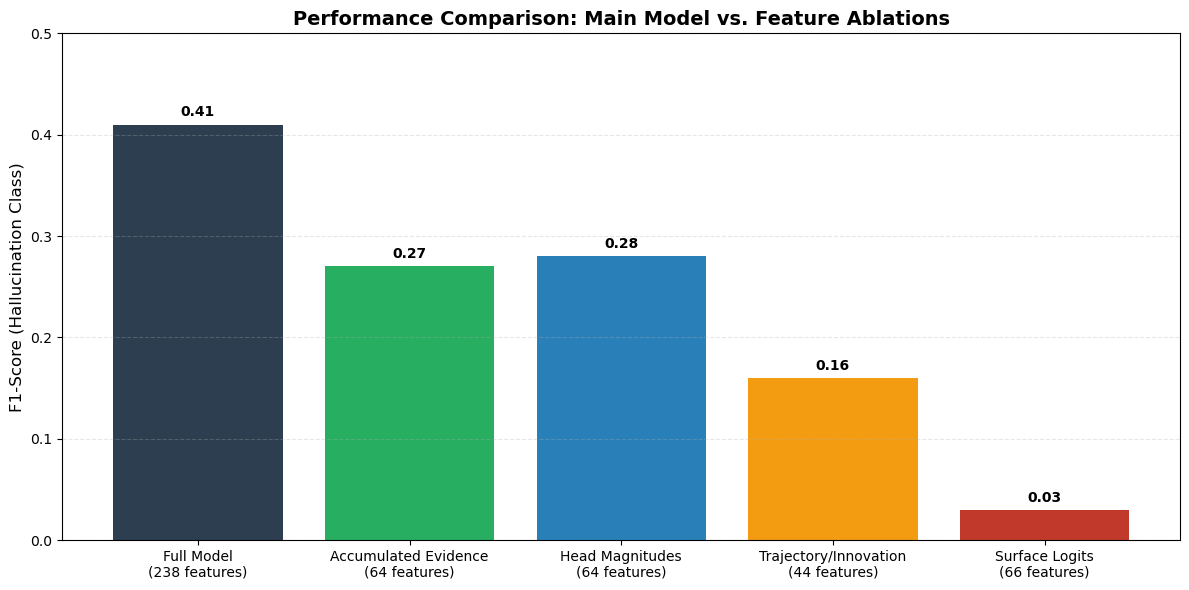

In [24]:
# Data updated from your latest 5-Fold CV Logs
models = [
    'Full Model\n(238 features)',
    'Accumulated Evidence\n(64 features)',
    'Head Magnitudes\n(64 features)',
    'Trajectory/Innovation\n(44 features)',
    'Surface Logits\n(66 features)'
]

# Updated F1-scores from your latest K-Fold reports
f1_scores = [
    0.41, # Final CV Results: 0.4083
    0.27, # Ablation 1 Result
    0.28, # Ablation 2 Result
    0.16, # Ablation 3 Result
    0.03  # Ablation 4 Result
]

plt.figure(figsize=(12, 6))
colors = ['#2c3e50', '#27ae60', '#2980b9', '#f39c12', '#c0392b']
bars = plt.bar(models, f1_scores, color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.title('Performance Comparison: Main Model vs. Feature Ablations', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (Hallucination Class)', fontsize=12)
plt.ylim(0, 0.50) # Increased to accommodate the 0.41 score
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

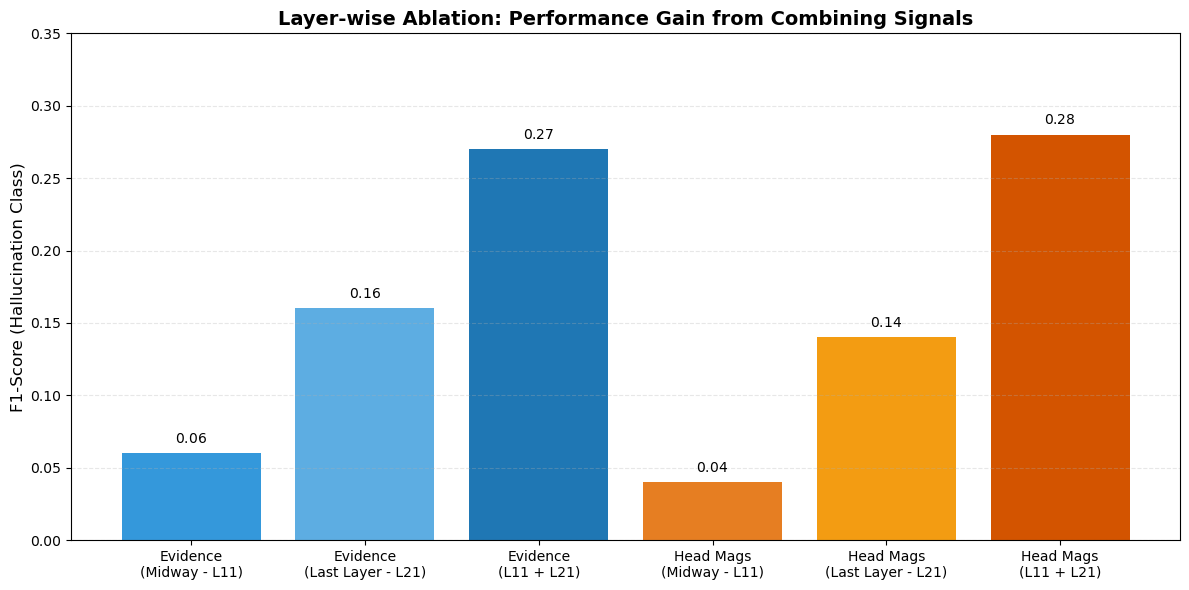

In [25]:
# Data in new order: Isolated first, then combined
labels = [
    'Evidence\n(Midway - L11)', 
    'Evidence\n(Last Layer - L21)',
    'Evidence\n(L11 + L21)', 
    'Head Mags\n(Midway - L11)', 
    'Head Mags\n(Last Layer - L21)',
    'Head Mags\n(L11 + L21)'
]

f1_scores = [0.06, 0.16, 0.27, 0.04, 0.14, 0.28]

# Colors: Shifting to match new order
# Isolated (lighter) -> Combined (darker)
colors = [
    '#3498db', '#5dade2', '#1f77b4',  # Evidence: L11, L21, Combined
    '#e67e22', '#f39c12', '#d35400'   # Head Mags: L11, L21, Combined
]

plt.figure(figsize=(12, 6))
bars = plt.bar(labels, f1_scores, color=colors)

# Add text labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'${yval:.2f}$',
             ha='center', va='bottom', fontweight='bold')

plt.title('Layer-wise Ablation: Performance Gain from Combining Signals', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (Hallucination Class)', fontsize=12)
plt.ylim(0, 0.35)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('layer_wise_ablation_reordered.png')

[-0.01914675 -0.01250816 -0.03341054 -0.02796453 -0.02788206 -0.0062627
 -0.0240885  -0.02349189 -0.014898   -0.01024367  0.00639396 -0.00308547
 -0.01347563  0.00600403  0.01559937 -0.01687919 -0.03244779 -0.04786362
 -0.05602235 -0.03371908 -0.01930927  0.01032171]
[ 0.01226099  0.01059064 -0.03172371 -0.0101972   0.00944133 -0.0098743
 -0.00458372 -0.00826706 -0.0228025   0.00683869 -0.00278711 -0.02740488
  0.00043778 -0.01020644 -0.04025284 -0.05189672 -0.02020993  0.00276836
  0.02062491  0.06633785  0.0475074   0.0158905 ]


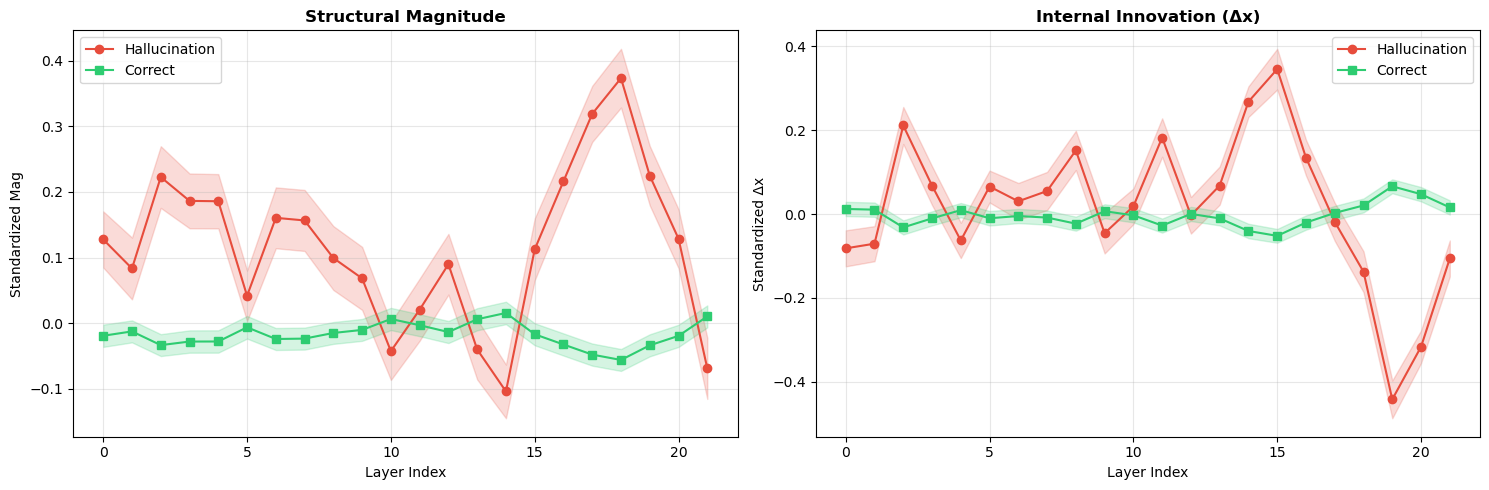

In [26]:
# Normalize based only on training fold data
X_mean = X_tensor.mean(dim=0)
X_std = X_tensor.std(dim=0) + 1e-4

X_standardized = ((X_tensor - X_mean) / X_std).to(model.device)
plot_trajectory_comparison(X_standardized, y_tensor)

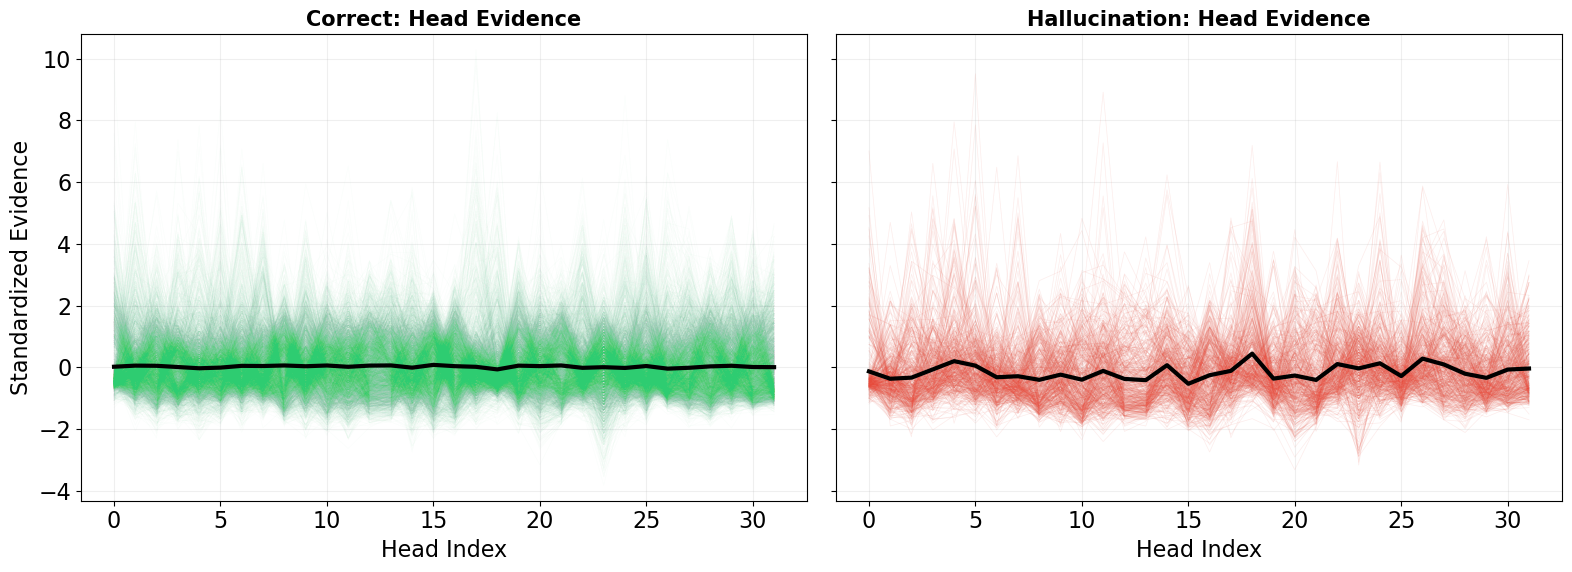

In [27]:
plot_evidence_distribution(X_standardized, y_tensor, 32, 64, label='Evidence')

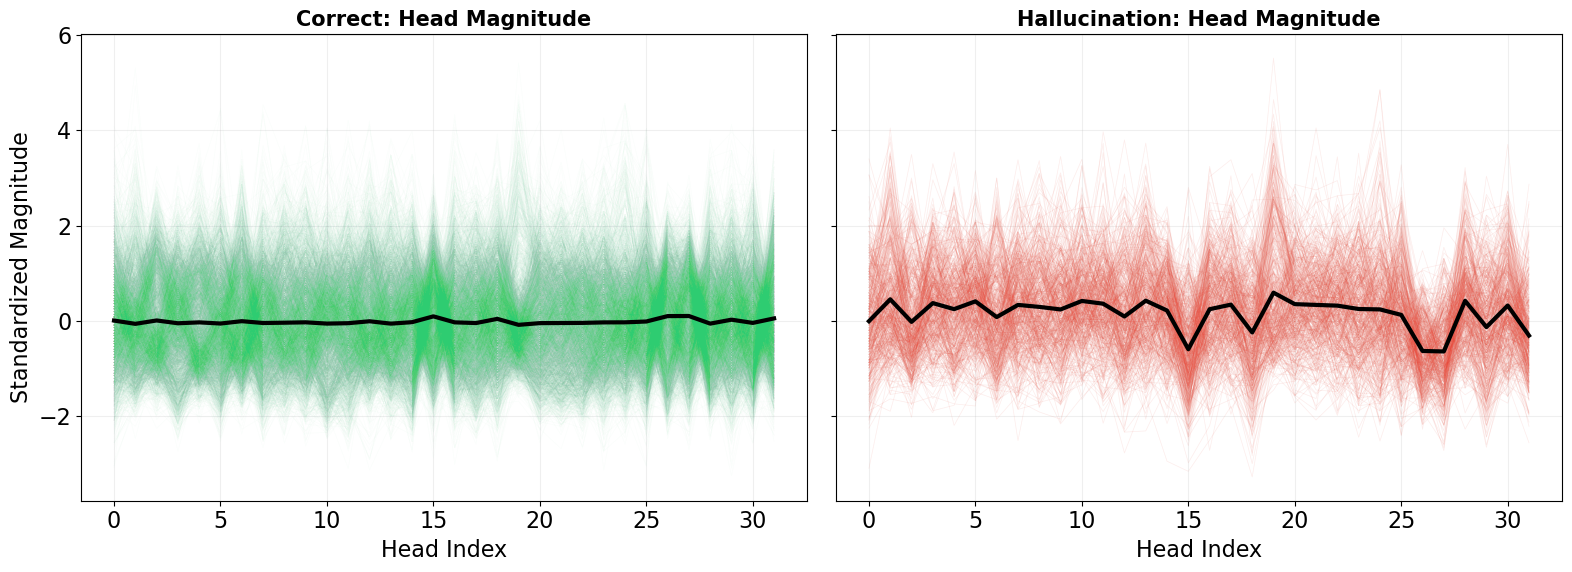

In [28]:
plot_evidence_distribution(X_standardized, y_tensor, 96, 128, label='Magnitude')